# Fase 1 — EDA: distribuciones demográficas y de adquisición

Segunda tarea de la Fase 1 (ver `FASES.md`): edad, sexo, frecuencia de muestreo y duración nominal por dataset. Todo sale de `metadata.parquet` (sin tocar los HDF5), así que corre sobre los 366.854 registros completos, no sobre una muestra.

Por qué importa: edad y sexo son posibles *confounders* (si Chagas+ y Chagas- difieren sistemáticamente en edad, un modelo puede aprender a detectar edad en vez de Chagas); y comparar poblaciones entre datasets ayuda a anticipar qué tan bien puede generalizar un modelo entrenado combinándolos.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np

from eda_utils import cargar_metadata

meta = cargar_metadata()
DATASETS = ["code15", "samitrop", "ptbxl"]
COLORES = {"code15": "#1f5fa8", "samitrop": "#c0392b", "ptbxl": "#2c8a4b"}
len(meta)

366854

## Edad

In [2]:
meta.groupby("dataset")["edad"].describe()

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
code15,343424.0,53.188356,19.701631,17.0,37.0,54.0,70.0,100.0
ptbxl,21799.0,62.769301,32.308813,2.0,50.0,62.0,72.0,300.0
samitrop,1631.0,59.397302,12.791258,26.0,50.0,59.0,69.0,98.0


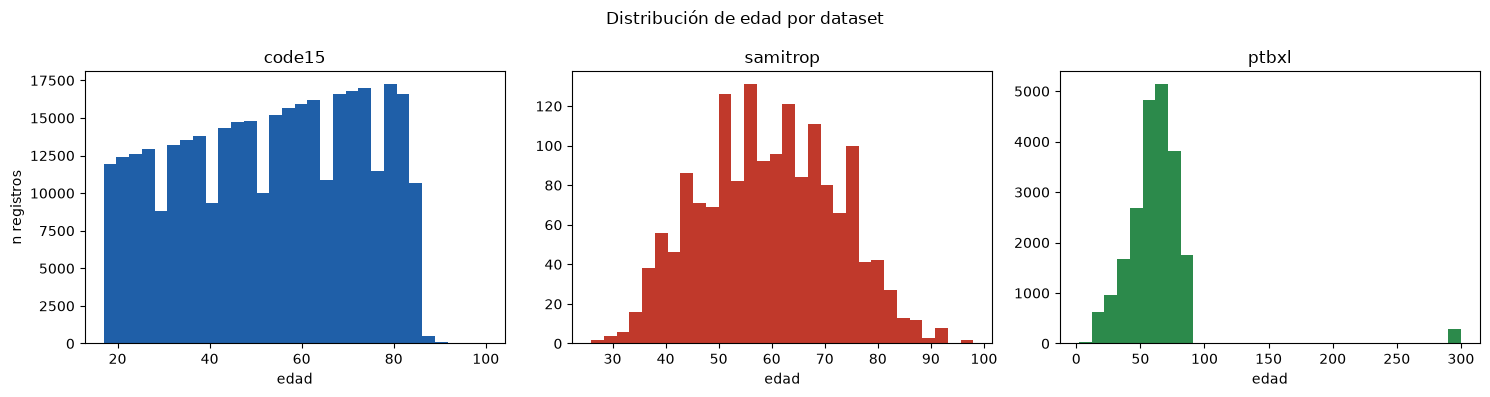

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, dataset in zip(axes, DATASETS):
    edad = meta.loc[meta["dataset"] == dataset, "edad"]
    ax.hist(edad, bins=30, color=COLORES[dataset])
    ax.set_title(dataset)
    ax.set_xlabel("edad")
axes[0].set_ylabel("n registros")
fig.suptitle("Distribución de edad por dataset")
fig.tight_layout()
plt.show()

### Edad por clase (dentro de cada dataset)

CODE-15% es el único dataset con ambas clases representadas en volumen suficiente para comparar esta distribución (SaMi-Trop es 100% positivo, PTB-XL 100% negativo-presunto).

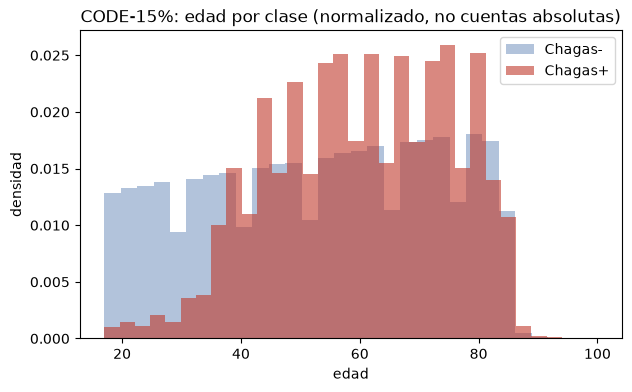

In [4]:
code15 = meta[meta["dataset"] == "code15"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(code15.loc[~code15["chagas_label"], "edad"], bins=30, alpha=0.6, label="Chagas-", color="#7f9cc4", density=True)
ax.hist(code15.loc[code15["chagas_label"], "edad"], bins=30, alpha=0.6, label="Chagas+", color="#c0392b", density=True)
ax.set_xlabel("edad")
ax.set_ylabel("densidad")
ax.set_title("CODE-15%: edad por clase (normalizado, no cuentas absolutas)")
ax.legend()
plt.show()

## Sexo

In [5]:
tabla_sexo = meta.groupby(["dataset", "sexo"]).size().unstack(fill_value=0)
tabla_sexo["% F"] = (tabla_sexo["F"] / (tabla_sexo["F"] + tabla_sexo["M"]) * 100).round(1)
tabla_sexo

sexo,F,M,% F
dataset,,,
code15,205046,138378,59.7
ptbxl,10445,11354,47.9
samitrop,1097,534,67.3


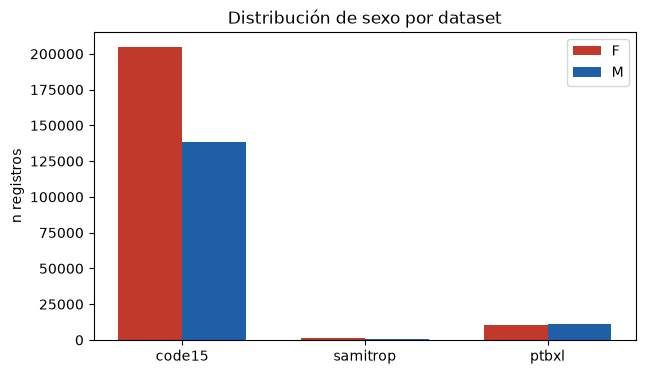

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(DATASETS))
ancho = 0.35
ax.bar(x - ancho / 2, [tabla_sexo.loc[d, "F"] for d in DATASETS], ancho, label="F", color="#c0392b")
ax.bar(x + ancho / 2, [tabla_sexo.loc[d, "M"] for d in DATASETS], ancho, label="M", color="#1f5fa8")
ax.set_xticks(x)
ax.set_xticklabels(DATASETS)
ax.set_ylabel("n registros")
ax.set_title("Distribución de sexo por dataset")
ax.legend()
plt.show()

## Frecuencia de muestreo y duración nominal

`frecuencia` y `duracion` en `metadata.parquet` son valores nominales fijos por dataset (no varían registro a registro), así que no tiene sentido un histograma — alcanza con la tabla, a modo de chequeo de consistencia contra lo que hardcodea `build_metadata.py`. La duración *real* de señal útil (descontando el padding de CODE-15%/SaMi-Trop) se mide en `04_calidad_senal.ipynb`, no acá.

In [7]:
meta.groupby("dataset")[["frecuencia", "duracion"]].agg(["min", "max", "nunique"])

frecuencia              duracion               
                min  max nunique      min    max nunique
dataset                                                 
code15          400  400       1    10.24  10.24       1
ptbxl           500  500       1    10.00  10.00       1
samitrop        400  400       1    10.24  10.24       1